In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [19]:
df=df.drop(columns=["Id"])

In [20]:
print(df.shape)
print(df.info())
print(df.describe())
print(df["Species"].value_counts())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max       

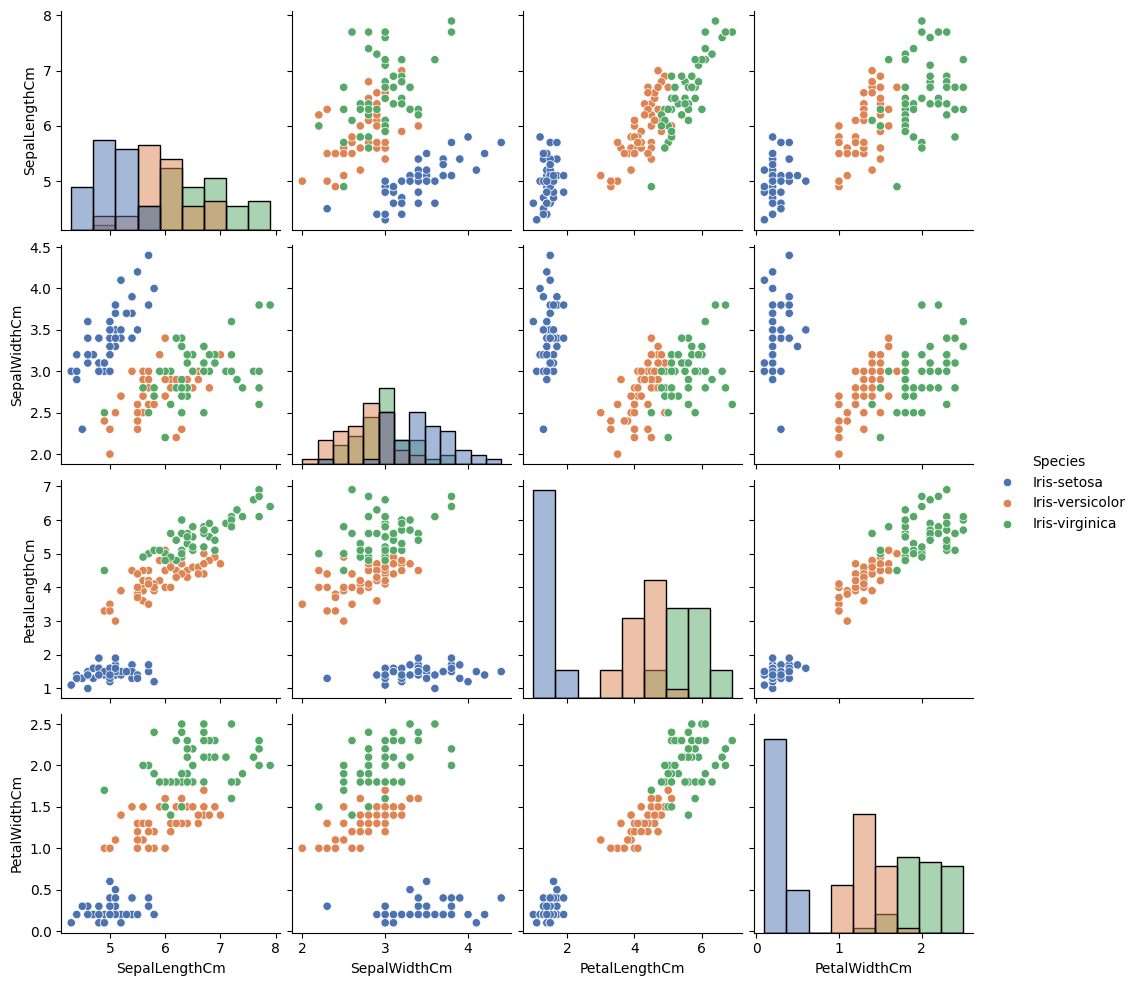

In [52]:
sns.pairplot(df, hue="Species", palette="deep", diag_kind="hist")
plt.savefig("pairplot.png", dpi=150)
plt.show()

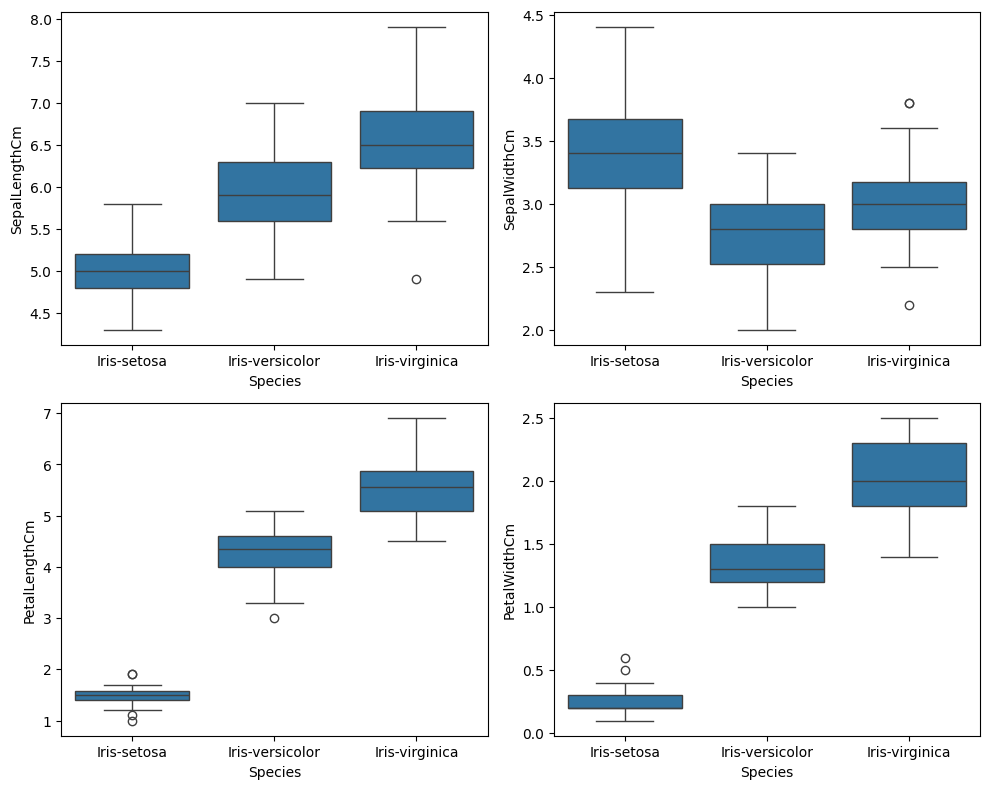

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feature, ax=ax)

plt.tight_layout()
plt.show()

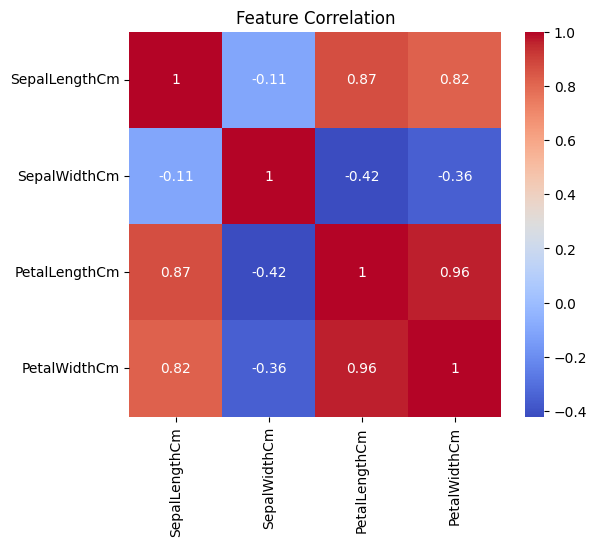

In [54]:
plt.figure(figsize=(6,5))
sns.heatmap(df.drop(columns=["Species"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [55]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(list(le.classes_))
print(y_encoded[:5], y_encoded[-5:])

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
[0 0 0 0 0] [2 2 2 2 2]


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel="linear", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9333
KNN: 0.9333
Decision Tree: 0.9000
SVM: 1.0000


In [60]:

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"Best model: {best_name} ({results[best_name]:.4f})")

Best model: SVM (1.0000)


In [61]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



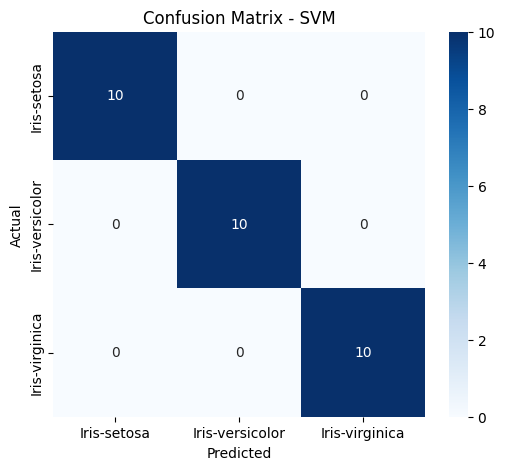

In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [73]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/iris_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le, "models/label_encoder.pkl")

print("Saved model, scaler, and label encoder.")

Saved model, scaler, and label encoder.


In [74]:
loaded_model = joblib.load("models/iris_model.pkl")
loaded_scaler = joblib.load("models/scaler.pkl")
loaded_encoder = joblib.load("models/label_encoder.pkl")

# a new flower's measurements — sepal_length, sepal_width, petal_length, petal_width
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
                       columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"])

sample_scaled = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_scaled)
predicted_species = loaded_encoder.inverse_transform(prediction)[0]

print(f"Predicted species: {predicted_species}")

Predicted species: Iris-setosa


In [75]:
from google.colab import files

# Images
files.download("pairplot.png")
files.download("confusion_matrix.png")

# Model artifacts
files.download("models/iris_model.pkl")
files.download("models/scaler.pkl")
files.download("models/label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'models', 'Iris.csv', 'confusion_matrix.png', 'pairplot.png', 'sample_data']
